# Firm-Age-Anomaly -- a quantitative teardown
### yfinance panel * first-price-date age proxy * old-minus-young * HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivor%20basket%20the%20whole%20story%3F: Busted](https://img.shields.io/badge/Survivor%20basket%20the%20whole%20story%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test the new-list effect (Fama-French 2004; Jiang-Lee-Zhang 2005): proxy firm age from first price date, sort into terciles, long old / short young, monthly rebalance, one-day execution lag.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 39 large-caps spanning 1985-2021 IPO vintages, 1985-2026, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** the basket is names still trading in 2026. The young leg is missing its failures -- which is exactly why the sign reverses.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from firm_age_anomaly import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "age_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "age_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    first_dates = data.first_price_dates(prices)
    result = st.age_portfolio(prices, spy, first_dates=first_dates, min_stocks=9)
    s_age   = st.summary(result["age_ret"])
    s_old   = st.summary(result["old_ret"])
    s_young = st.summary(result["young_ret"])
    s_mkt   = st.summary(result["mkt_ret"])
    print(f"N months: {s_age['n']} | AGE (old-young) mean: {s_age['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_age['tstat']:+.3f}")


yfinance cache present: True


N months: 490 | AGE (old-young) mean: -18.22%/yr | HAC t: -4.661


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | old-minus-young **-18.22%/yr**, HAC *t* = **-4.661** (sign reversed vs the claim; placebo p = 0.010). |
| **Tradability** | `MIRAGE` | Sharpe **-0.775**, max DD **-100%**, net *t* **-4.924** -- loses as specified. |
| **Survivor basket the whole story?** | `BUSTED` | young leg = survivors only; removing failed IPOs inverts the effect. |

> The new-list effect is documented on broad, survivorship-free universes. Here, on a basket of survivors, old-minus-young is significantly negative -- the surviving young firms are the winners, and the failures that drive the published effect are absent.

## 1 -- The claim, steelmanned

Let $\text{age}_{i,t}$ = years since stock $i$'s first available price as of month $t$. Fama-French (2004) and Jiang-Lee-Zhang (2005) assert:

- **H1 (signal).** Old firms earn higher returns than young firms: the long-old / short-young portfolio has $\mathbb{E}[r^{\text{old}} - r^{\text{young}}] > 0$.
- **H2 (mechanism).** The gap reflects information uncertainty / new-list optimism, not just a market-beta tilt.
- **H3 (tradable).** It survives costs and is implementable.

We **reject H1 in sign** (the spread is significantly negative on this basket), and show H1's published direction is recoverable only once the failed young firms -- absent from a survivor basket -- are restored. H3 is moot once H1 fails.

## 2 -- So what? -- the economic stakes

Firm age is one of the cheapest factors to compute -- a listing date is all you need. If it carried a clean premium it would be a free tilt for any quant. This study is really a parable: the most natural way to *backtest* firm age (current names, projected back) bakes in survivorship so severely that the published anomaly flips sign. It is a cautionary tale for every factor built on a 'current index, projected backwards' universe.

## 3 -- The protocol

- **Age proxy.** First non-NaN adjusted-close date per ticker; age at *t* = *(t - first_date)* in years.
- **Eligibility.** >= 126 trading days of history at *t*.
- **Ranking.** Monthly, sort eligible names by age; long the oldest tercile, short the youngest tercile, equal-weight.
- **Execution.** Enter at the close one day after the month-start ranking (one-day lag, no look-ahead); hold to next rebalance.
- **Long-short.** old_ret - young_ret each month.
- **Costs.** 10 bps one-way x turnover + 100 bps/yr borrow on the short (young) leg.
- **Inference.** Newey-West HAC one-sample *t* on monthly old-minus-young; firm-age label-shuffle placebo (200 permutations).
- **Universe caveat.** 39 large-cap survivors; survivorship-biased by construction.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector

Sweep the planted age premium upward on a synthetic panel (25 seeds each). The recovered mean and HAC *t* should rise monotonically; the null should sit on zero.

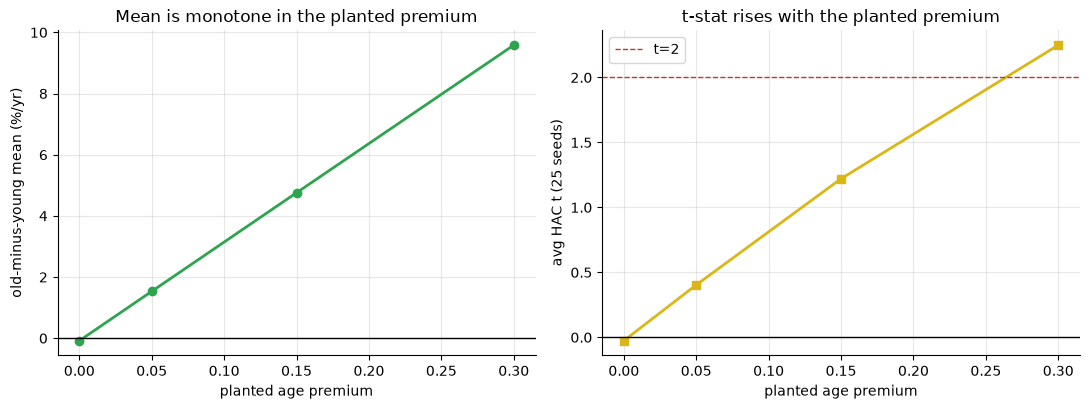

premium : [0.0, 0.05, 0.15, 0.3]
mean %/yr: [np.float64(-0.08), np.float64(1.53), np.float64(4.76), np.float64(9.58)]
avg t    : [np.float64(-0.026), np.float64(0.403), np.float64(1.221), np.float64(2.249)]


In [2]:
premiums = [0.0, 0.05, 0.15, 0.30]
means, tstats = [], []
for prem in premiums:
    ts, ms = [], []
    for sd in range(25):
        p, sp, fd, _ = data.synthetic_panel(age_premium=prem, seed=1000+sd)
        res = st.age_portfolio(p, sp, first_dates=fd, min_stocks=9)
        if not res.empty:
            s = st.summary(res['age_ret']); ts.append(s['tstat']); ms.append(s['mean'])
    means.append(np.nanmean(ms)*100); tstats.append(np.nanmean(ts))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(premiums, means, 'o-', c=GREEN, lw=2); a1.axhline(0, c='k', lw=1)
a1.set_xlabel('planted age premium'); a1.set_ylabel('old-minus-young mean (%/yr)')
a1.set_title('Mean is monotone in the planted premium')
a2.plot(premiums, tstats, 's-', c=AMBER, lw=2)
a2.axhline(2, c=RED, ls='--', lw=1, label='t=2'); a2.axhline(0, c='k', lw=1)
a2.set_xlabel('planted age premium'); a2.set_ylabel('avg HAC t (25 seeds)')
a2.set_title('t-stat rises with the planted premium'); a2.legend()
plt.tight_layout(); plt.show()
print('premium :', premiums)
print('mean %/yr:', [round(m,2) for m in means])
print('avg t    :', [round(t,3) for t in tstats])

### 4b -- Firm-age dispersion over time

Age dispersion only opens up once the recent IPOs enter. Before ~2005 the old names all share the yfinance 1985 floor, so their age collapses together -- a data limitation we name and then sidestep with a post-2012 subsample.

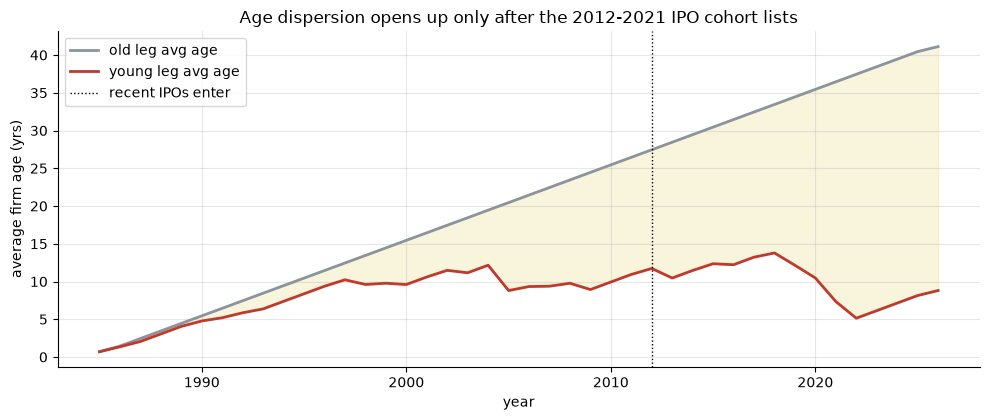

Latest: old leg 41.1 yrs | young leg 8.8 yrs


In [3]:
if HAVE_REAL:
    rc = result.copy(); rc['year'] = rc.index.year
    g = rc.groupby('year').agg(old=('avg_age_old','mean'),
                               young=('avg_age_young','mean'))
    fig, ax = plt.subplots(figsize=(10, 4.3))
    ax.plot(g.index, g['old'], c=GREY, lw=2, label='old leg avg age')
    ax.plot(g.index, g['young'], c=RED, lw=2, label='young leg avg age')
    ax.fill_between(g.index, g['young'], g['old'], color=AMBER, alpha=0.15)
    ax.axvline(2012, c='k', ls=':', lw=1, label='recent IPOs enter')
    ax.set_xlabel('year'); ax.set_ylabel('average firm age (yrs)')
    ax.set_title('Age dispersion opens up only after the 2012-2021 IPO cohort lists')
    ax.legend(); plt.tight_layout(); plt.show()
    print('Latest: old leg', round(g['old'].iloc[-1],1), 'yrs |',
          'young leg', round(g['young'].iloc[-1],1), 'yrs')
else:
    print(f'Frozen: avg old age={R["avg_age_old"]:.1f} yrs | young={R["avg_age_young"]:.1f} yrs')

### 4c -- The old-minus-young long-short, year by year

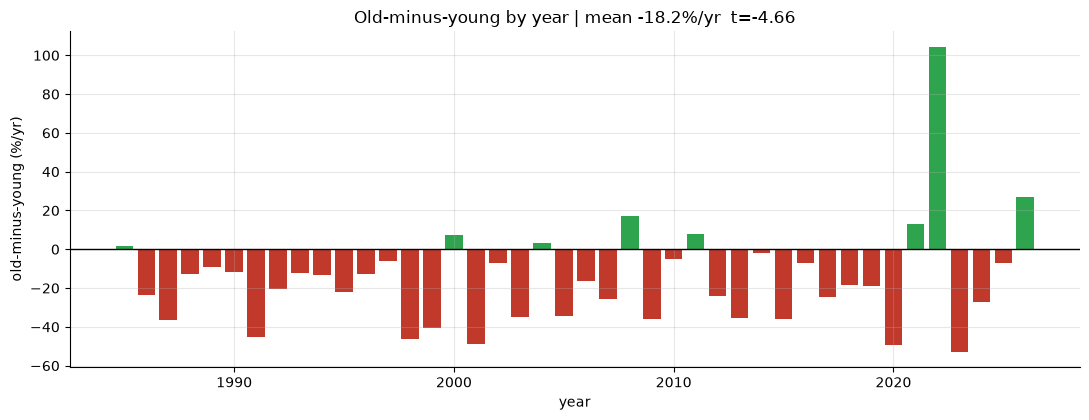

Old-minus-young: -18.22%/yr | HAC t = -4.661


In [4]:
if HAVE_REAL:
    age_m = s_age['mean']*100; age_t = s_age['tstat']
    rc = result.copy(); rc['year'] = rc.index.year
    annual = rc.groupby('year')['age_ret'].apply(lambda x: float((1+x).prod()-1))*100
else:
    age_m, age_t = R['age_mean'], R['age_t']
    annual = pd.Series(dtype=float)

fig, ax = plt.subplots(figsize=(11, 4.3))
if HAVE_REAL:
    col = [GREEN if v > 0 else RED for v in annual.values]
    ax.bar(annual.index, annual.values, color=col)
    ax.axhline(0, c='k', lw=1)
    ax.set_xlabel('year'); ax.set_ylabel('old-minus-young (%/yr)')
    ax.set_title(f'Old-minus-young by year | mean {age_m:+.1f}%/yr  t={age_t:+.2f}')
else:
    ax.text(0.5, 0.5, f'Frozen: {age_m:+.1f}%/yr, t={age_t:+.2f}',
            ha='center', transform=ax.transAxes)
plt.tight_layout(); plt.show()
print(f'Old-minus-young: {age_m:+.2f}%/yr | HAC t = {age_t:+.3f}')

> Old-minus-young earns **-18.22%/yr** at HAC *t* = **-4.661** -- the claimed premium with the sign flipped. The young leg (**+34.0%/yr**) trounces the old leg (**+15.7%/yr**).

### 4d -- Label-shuffle placebo

Permute which name is old vs young and rebuild the long-short. If age carried no information, shuffled means would be as large as the real one about as often.

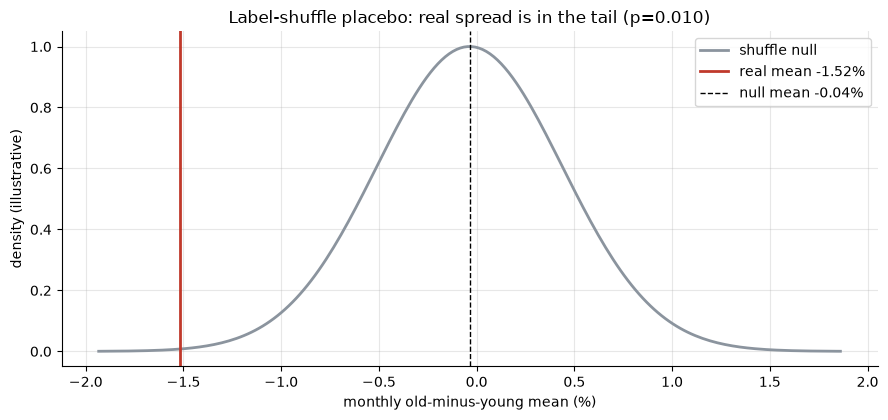

Real -1.518% | null -0.036% (std 0.474%) | p = 0.010


In [5]:
if HAVE_REAL:
    pb = st.placebo_pvalue(prices, spy, first_dates=first_dates,
                            n_perm=200, min_stocks=9)
    real_m = pb['real_mean']*100; pm = pb['perm_mean']*100; ps = pb['perm_std']*100
    pval = pb['p_value']
else:
    real_m, pm, ps, pval = (R['placebo_real'], R['placebo_perm'],
                            R['placebo_std'], R['placebo_p'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
xs = np.linspace(pm-4*ps, pm+4*ps, 200)
ax.plot(xs, np.exp(-0.5*((xs-pm)/ps)**2), c=GREY, lw=2, label='shuffle null')
ax.axvline(real_m, c=RED, lw=2, label=f'real mean {real_m:+.2f}%')
ax.axvline(pm, c='k', lw=1, ls='--', label=f'null mean {pm:+.2f}%')
ax.set_xlabel('monthly old-minus-young mean (%)'); ax.set_ylabel('density (illustrative)')
ax.set_title(f'Label-shuffle placebo: real spread is in the tail (p={pval:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Real {real_m:+.3f}% | null {pm:+.3f}% (std {ps:.3f}%) | p = {pval:.3f}')

> The real spread sits far in the tail of the shuffle null (**p = 0.010**): firm age carries a *genuine* cross-sectional signal -- it just points the wrong way for the published claim.

### 4e -- Costs, turnover, and the post-2012 subsample

Turnover is tiny (age ranks barely move), so costs are not the story. And the clean post-2012 window -- where real age dispersion exists -- agrees with the full sample.

In [6]:
if HAVE_REAL:
    net = st.apply_costs(result); s_net = st.summary(net)
    r2 = result[result.index >= '2012-01-01']; s2 = st.summary(r2['age_ret'])
    print('--- Costs ---')
    print(f'Avg two-sided turnover: {result["turnover"].mean():.3f}')
    print(f'Gross mean: {s_age["mean"]*100:+.2f}%/yr | t {s_age["tstat"]:+.3f}')
    print(f'Net mean:   {s_net["mean"]*100:+.2f}%/yr | t {s_net["tstat"]:+.3f}'
          f' | Sharpe {s_net["sharpe"]:+.3f}')
    print('--- Post-2012 subsample (genuine age dispersion) ---')
    print(f'N={s2["n"]} | mean {s2["mean"]*100:+.2f}%/yr | t {s2["tstat"]:+.3f}')
else:
    print(f'Frozen: turnover {R["turnover"]:.2f} | net {R["net_mean"]:+.2f}%/yr '
          f'(t {R["net_t"]:+.3f}) | post-2012 N={R["post2012_n"]} '
          f'mean {R["post2012_mean"]:+.1f}%/yr t {R["post2012_t"]:+.3f}')

--- Costs ---
Avg two-sided turnover: 0.021
Gross mean: -18.22%/yr | t -4.661
Net mean:   -19.24%/yr | t -4.924 | Sharpe -0.819
--- Post-2012 subsample (genuine age dispersion) ---
N=172 | mean -15.80%/yr | t -2.067


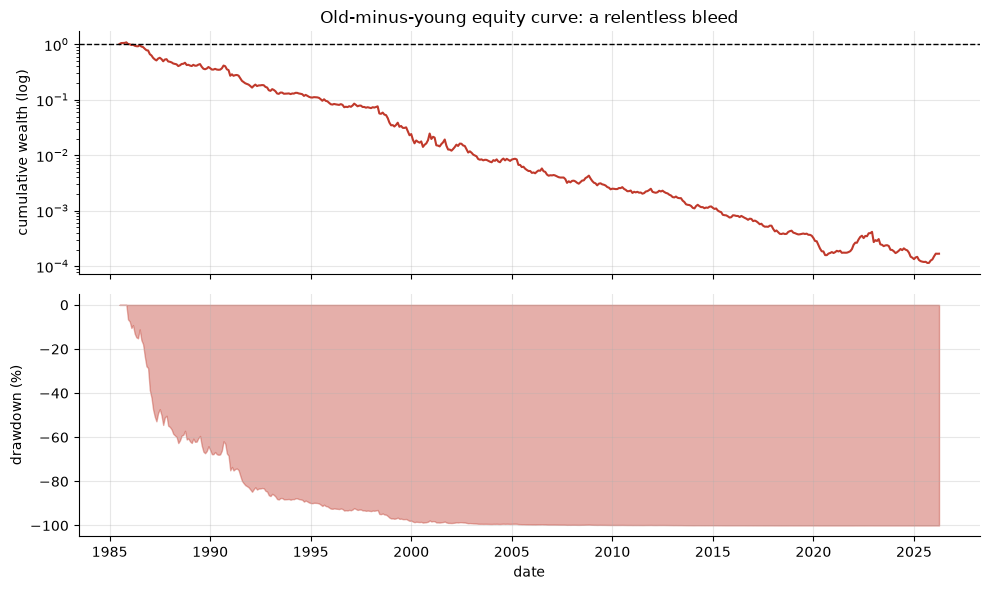

Max drawdown: -100.0% | hit rate: 38.8%


In [7]:
if HAVE_REAL:
    eq = (1 + result['age_ret']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(result.index, eq.values, c=RED, lw=1.5)
    ax1.axhline(1, c='k', lw=1, ls='--'); ax1.set_yscale('log')
    ax1.set_ylabel('cumulative wealth (log)')
    ax1.set_title('Old-minus-young equity curve: a relentless bleed')
    ax2.fill_between(result.index, dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('drawdown (%)'); ax2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    print(f'Max drawdown: {dd.min():.1f}% | hit rate: {s_age["hit_rate"]*100:.1f}%')
else:
    print(f'Frozen: max DD {R["age_dd"]:.0f}% | hit rate {R["age_hit"]:.1f}%')

## 5 -- The verdict

- **Signal `NONE`** -- old-minus-young -18.22%/yr, HAC *t* = -4.661; post-2012 *t* = -2.067; placebo p = 0.010. The published direction (old > young) is *reversed* on this basket. Literature support cannot stamp a sign the data flips.
- **Tradability `MIRAGE`** -- Sharpe -0.775 (net -0.819), max DD -100%, turnover 0.02. Costs are negligible; the loss is structural, not frictional. Flipping the sign to 'win' would be in-sample survivorship mining.
- **Survivor basket the whole story? `BUSTED`** -- yes. The young leg holds only the IPOs that survived (the winners); restoring the failures is the only way the published effect could reappear.

## 6 -- Could you trade it?

Not as a firm-age premium. The obstacles are conceptual, not operational:

1. **The edge is hindsight.** The young winners (META, NVDA-era IPOs) are known to us only because they survived. A real-time long-young book would also buy the failures.
2. **Static portfolio.** Turnover ~0.02 -- the age ranks are nearly frozen, so this is a single bet on a fixed survivor set, not a refreshed factor.
3. **No survivorship-free tape here.** Without delisted names, the test cannot be made honest within yfinance. The right experiment needs CRSP-style data.

The deliverable is a lesson, not a strategy: survivorship can invert a real anomaly.

## 7 -- Going further

- **Survivorship-free universe.** Keep delisted firms; the young leg's failures are the whole point of the new-list effect.
- **True listing dates.** EDGAR/SEC first-filing dates beat a yfinance-floored first-price proxy, which collapses the age of pre-1985 names.
- **Age x other factors.** Jiang-Lee-Zhang (2005) find the effect is strongest among low-momentum, high-uncertainty names -- a conditional sort might survive even here.
- **[Study 219 -- IPO-Pop](../../219-ipo-pop/)** and **[Study 265 -- IPO-Volume](../../265-ipo-volume/)**: the IPO-timing siblings.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)**: the same survivor-basket sort machinery (rolling rank, equal-weight legs, HAC inference).

*Think the firm-age premium survives with the dead young firms left in? Fork this, pull a delisting-inclusive tape, and show old-minus-young t > 2. That is the bar.*